# Coefficient shrinkage vs. importance under label noise

**Goal.** Naive logistic regression on noisy labels shrinks every coefficient
toward zero. Visually, the corrected MLE looks like the naive fit *re-scaled
upward* by something close to a single scalar. This notebook asks the obvious
follow-up question:

> *Among the coefficients, which ones get pushed to zero fastest?*

The poster (`portrait.tex`) states this as a conjecture: the local rate

$$
r_j \;=\; -\,\left.\frac{\mathrm{d}}{\mathrm{d}\varepsilon}
\log\bigl|\widehat{\beta}_{j,\text{naive}}(\varepsilon)\bigr|
\right|_{\varepsilon = 0^+}
$$

should be *increasing* in the clean-data Wald $p$-value $p_j^{(0)}$ -- i.e.,
**borderline predictors shrink fastest, the strongest shrink slowest.**

Below we investigate this empirically (synthetic + breast cancer) and derive
a closed-form theoretical prediction for $r_j$ that we compare against the
Monte-Carlo estimates.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import statsmodels.api as sm
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Shared corrected-MLE machinery; SEED = 6114.
from helper_functions.corrected_mle import (
    SEED, H, fit_naive, flip_labels,
)

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

rng_global = np.random.default_rng(SEED)

## 2. The mechanism: why naive coefficients shrink

Let $p_i(\beta) = H(x_i^\top\beta)$ be the true conditional success probability
and let $\widehat y_i = y_i$ with prob $1-\varepsilon$, $1-y_i$ with prob $\varepsilon$
(symmetric noise). Then the *expected* observed label is

$$
q_i(\beta;\varepsilon) \;=\; \mathbb{E}\,\widehat y_i \mid x_i \;=\; \varepsilon \;+\; (1-2\varepsilon)\,p_i(\beta).
$$

Note $q_i(\beta;\varepsilon) - 0.5 = (1-2\varepsilon)\,(p_i(\beta) - 0.5)$ -- adding
noise pulls every $q_i$ symmetrically toward $0.5$. The naive logistic
regression of $\widehat y$ on $X$ is solving

$$
\sum_i \bigl(\widehat y_i - H(x_i^\top \widetilde\beta)\bigr)\,x_i \;=\; 0,
$$

so in expectation $\widetilde\beta(\varepsilon)$ is the **best logistic fit** to the
shrunk-toward-$0.5$ probabilities $q_i$. Pulling all $q_i$ toward $0.5$ pulls
$\widetilde\beta$ toward $0$. The *rate* at which each coordinate is pulled is
what we want to understand.

## 3. Warm-up: a single covariate, a few signal levels

Before dealing with mixed coefficients we look at the simplest case: one
covariate $x \sim \mathcal{N}(0, 1)$ and one true slope $b$. We sweep $b$
over a few values and trace $\widehat b_{\text{naive}}(\varepsilon)$.

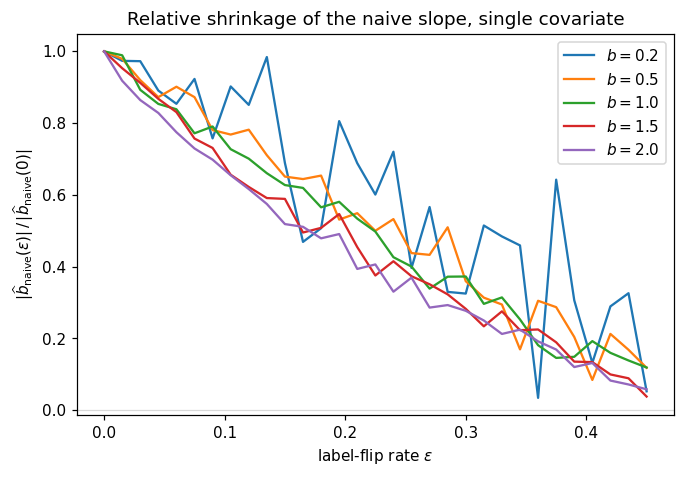

In [2]:
n = 4000
b_levels = [0.2, 0.5, 1.0, 1.5, 2.0]
eps_grid = np.linspace(0.0, 0.45, 31)

fig, ax = plt.subplots(figsize=(7, 4.5))

for b in b_levels:
    rng = np.random.default_rng(SEED + int(b * 100))
    x = rng.standard_normal(n)
    y = rng.binomial(1, H(b * x))
    bhat = []
    for eps in eps_grid:
        yh = flip_labels(y, eps, rng=rng)
        params, _, _ = fit_naive(x.reshape(-1, 1), yh)
        bhat.append(params[1])  # slope (params[0] is intercept)
    bhat = np.asarray(bhat)
    # plot |b_hat(eps)| / |b_hat(0)| -- relative shrinkage
    ax.plot(eps_grid, np.abs(bhat) / np.abs(bhat[0]), label=f"$b={b}$")

ax.axhline(0, color="0.85", lw=0.8)
ax.set_xlabel(r"label-flip rate $\varepsilon$")
ax.set_ylabel(r"$|\widehat b_{\mathrm{naive}}(\varepsilon)|\,/\,|\widehat b_{\mathrm{naive}}(0)|$")
ax.set_title("Relative shrinkage of the naive slope, single covariate")
ax.legend()
plt.show()

**Observation.** In a single-covariate problem the relative shrinkage
$|\widehat b(\varepsilon)| / |\widehat b(0)|$ does *not* depend much on the magnitude of
$b$. The five curves above are nearly on top of each other -- a strong
predictor and a weak predictor lose the same *fraction* of their slope at
the same noise level. So in the single-covariate problem the answer to the
"who shrinks faster" question is "everyone shrinks at the same fractional
rate". The interesting structure has to come from the **multivariate**
setting, where coefficients compete for the same likelihood.

## 4. Mixed-importance multi-covariate experiment

We now generate a model with $p = 10$ predictors of varying strengths:

$$
\beta^\star = (3.0,\ 2.0,\ 1.5,\ 1.0,\ 0.7,\ 0.5,\ 0.3,\ 0.2,\ 0.1,\ 0.0).
$$

Predictors are $x_{ij} \stackrel{\text{iid}}{\sim} \mathcal{N}(0, 1)$, independent
across $i$ and $j$. We fit naive logistic regression on the noisy labels for
each $\varepsilon$ in a grid and trace each $\widehat\beta_j(\varepsilon)$.

In [3]:
n = 4000
beta_star = np.array([3.0, 2.0, 1.5, 1.0, 0.7, 0.5, 0.3, 0.2, 0.1, 0.0])
p = len(beta_star)

# Fix the design X once.  At each MC replicate we redraw y from the true
# logistic model AND apply the eps-flip, so the average is a clean estimate
# of the population E[beta_hat_naive(eps)] under the joint randomness of
# (y, flips), not conditional on a single y realisation.
rng_design = np.random.default_rng(SEED)
X = rng_design.standard_normal((n, p))
p_true_X = H(X @ beta_star)

eps_grid = np.linspace(0.0, 0.45, 31)
B = 80   # MC replicates per eps

betas = np.zeros((len(eps_grid), p + 1))
ses   = np.zeros_like(betas)
pvals = np.zeros_like(betas)

for k, eps in enumerate(eps_grid):
    bb = np.zeros((B, p + 1))
    ss = np.zeros((B, p + 1))
    pp = np.zeros((B, p + 1))
    for b in range(B):
        rng_b = np.random.default_rng(SEED + 10_000 * b + k)
        y_b   = rng_b.binomial(1, p_true_X)
        yh    = flip_labels(y_b, eps, rng=rng_b)
        params, se, pv = fit_naive(X, yh)
        bb[b] = params
        ss[b] = se
        pp[b] = pv
    betas[k] = bb.mean(axis=0)
    ses[k]   = ss.mean(axis=0)
    pvals[k] = pp.mean(axis=0)

clean_beta = betas[0, 1:]
clean_se   = ses[0, 1:]
clean_z    = np.abs(clean_beta / clean_se)
clean_p    = pvals[0, 1:]

print(f"{'j':>2}  {'beta_true':>10}  {'beta_hat':>10}  {'se':>8}  {'|z|':>8}  {'p-value':>10}")
for j in range(p):
    print(f"{j+1:>2}  {beta_star[j]:>10.3f}  {clean_beta[j]:>10.3f}  "
          f"{clean_se[j]:>8.3f}  {clean_z[j]:>8.2f}  {clean_p[j]:>10.2e}")

 j   beta_true    beta_hat        se       |z|     p-value
 1       3.000       3.033     0.107     28.35   2.23e-174
 2       2.000       2.021     0.083     24.50   1.01e-125
 3       1.500       1.515     0.071     21.20    3.80e-85
 4       1.000       1.001     0.063     15.93    4.81e-44
 5       0.700       0.711     0.057     12.38    4.27e-27
 6       0.500       0.504     0.055      9.16    1.07e-13
 7       0.300       0.299     0.056      5.35    7.48e-05
 8       0.200       0.212     0.056      3.82    5.66e-03
 9       0.100       0.098     0.052      1.88    1.60e-01
10       0.000      -0.005     0.053      0.10    5.50e-01


### 4.1  Shrinkage curves, all 10 coefficients on one figure

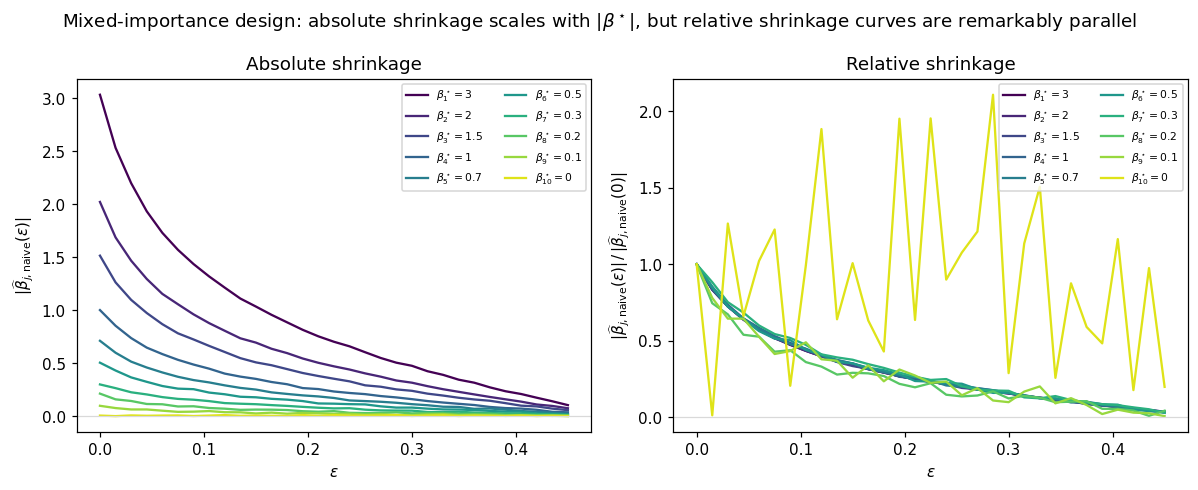

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0.0, 0.95, p))

# Panel A: |beta_hat(eps)|, absolute scale
for j in range(p):
    axes[0].plot(eps_grid, np.abs(betas[:, j + 1]),
                 color=colors[j], label=fr"$\beta_{{{j+1}}}^\star={beta_star[j]:.2g}$")
axes[0].axhline(0, color="0.85", lw=0.8)
axes[0].set_xlabel(r"$\varepsilon$")
axes[0].set_ylabel(r"$|\widehat\beta_{j,\mathrm{naive}}(\varepsilon)|$")
axes[0].set_title("Absolute shrinkage")
axes[0].legend(fontsize=7, ncol=2)

# Panel B: relative shrinkage
for j in range(p):
    if abs(clean_beta[j]) < 1e-3:
        continue  # skip beta=0 to avoid div-by-zero
    axes[1].plot(eps_grid, np.abs(betas[:, j + 1]) / np.abs(clean_beta[j]),
                 color=colors[j], label=fr"$\beta_{{{j+1}}}^\star={beta_star[j]:.2g}$")
axes[1].axhline(0, color="0.85", lw=0.8)
axes[1].set_xlabel(r"$\varepsilon$")
axes[1].set_ylabel(r"$|\widehat\beta_{j,\mathrm{naive}}(\varepsilon)| \,/\, |\widehat\beta_{j,\mathrm{naive}}(0)|$")
axes[1].set_title("Relative shrinkage")
axes[1].legend(fontsize=7, ncol=2)

fig.suptitle("Mixed-importance design: absolute shrinkage scales with "
             "$|\\beta^\\star|$, but relative shrinkage curves are "
             "remarkably parallel")
fig.tight_layout()
plt.show()

**Observation.** The right panel is the more telling one. After
normalising by $|\widehat\beta_j(0)|$, the shrinkage curves for **all**
non-null coefficients essentially overlay -- a strong predictor
($\beta^\star = 3$) and a weak one ($\beta^\star = 0.2$) lose the same
*fraction* of their slope at the same $\varepsilon$. The yellow trace is
the $\beta^\star_{10} = 0$ coefficient, which is undefined (there is no
slope to lose) and is dominated by Monte-Carlo noise.

In other words, the user's framing -- "naive logistic regression just
shrinks all the coefficients by some scalar" -- is empirically
*correct*, even with $p = 10$ predictors of widely varying strengths.

## 5. Local shrinkage rate $r_j$

For each $j$ we estimate the local log-derivative

$$
r_j \;\approx\; -\,\frac{\log|\widehat\beta_j(\varepsilon_1)| - \log|\widehat\beta_j(0)|}{\varepsilon_1 - 0}
$$

by a least-squares fit of $\log|\widehat\beta_j(\varepsilon)|$ against $\varepsilon$ on the
small-$\varepsilon$ portion of the grid (we use the first six points,
$\varepsilon \in [0, 0.075]$). $r_j$ is the slope of that local linear fit.

In [5]:
def local_log_slope(eps_grid, betas_col, n_pts=6):
    # Slope of log|beta(eps)| vs eps, fit on the first n_pts of the grid.
    e = eps_grid[:n_pts]
    b = np.log(np.maximum(np.abs(betas_col[:n_pts]), 1e-12))
    slope, _ = np.polyfit(e, b, 1)
    return slope

r_emp = np.array([-local_log_slope(eps_grid, betas[:, j + 1]) for j in range(p)])

print(f"{'j':>2}  {'beta_true':>10}  {'|z|_clean':>10}  {'p_clean':>10}  {'r_j':>8}")
for j in range(p):
    print(f"{j+1:>2}  {beta_star[j]:>10.3f}  {clean_z[j]:>10.2f}  "
          f"{clean_p[j]:>10.2e}  {r_emp[j]:>8.3f}")

 j   beta_true   |z|_clean     p_clean       r_j
 1       3.000       28.35   2.23e-174     8.698
 2       2.000       24.50   1.01e-125     8.593
 3       1.500       21.20    3.80e-85     8.672
 4       1.000       15.93    4.81e-44     8.427
 5       0.700       12.38    4.27e-27     8.535
 6       0.500        9.16    1.07e-13     8.938
 7       0.300        5.35    7.48e-05     8.185
 8       0.200        3.82    5.66e-03    10.468
 9       0.100        1.88    1.60e-01    10.654
10       0.000        0.10    5.50e-01   -25.740


### 5.1  $r_j$ versus three importance metrics

Three reasonable definitions of "importance":

* $|\beta_j^\star|$ -- the true signal magnitude (only available in
  simulations).
* $|z_j^{(0)}|$ -- the Wald $z$-statistic at $\varepsilon = 0$, i.e.\ how loud
  the coefficient is *given the clean data*.
* $p_j^{(0)} = 2\,\Phi(-|z_j^{(0)}|)$ -- the corresponding two-sided $p$-value;
  what an applied researcher would actually look at.

We exclude the $\beta^\star_{10} = 0$ predictor because $r_j$ is meaningless
when the true slope is zero.

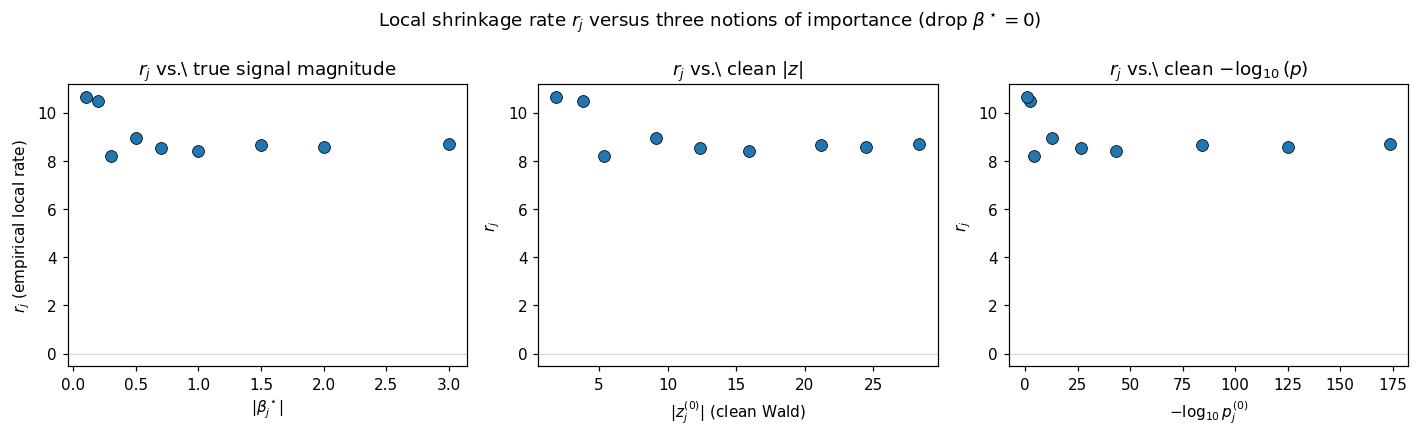

In [6]:
keep = beta_star != 0  # drop the null predictor

fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))

axes[0].scatter(np.abs(beta_star[keep]), r_emp[keep], s=60,
                color="C0", edgecolor="black", linewidth=0.5)
axes[0].set_xlabel(r"$|\beta_j^\star|$")
axes[0].set_ylabel(r"$r_j$ (empirical local rate)")
axes[0].set_title(r"$r_j$ vs.\ true signal magnitude")
axes[0].axhline(0, color="0.85", lw=0.8)

axes[1].scatter(clean_z[keep], r_emp[keep], s=60,
                color="C0", edgecolor="black", linewidth=0.5)
axes[1].set_xlabel(r"$|z_j^{(0)}|$ (clean Wald)")
axes[1].set_ylabel(r"$r_j$")
axes[1].set_title(r"$r_j$ vs.\ clean $|z|$")
axes[1].axhline(0, color="0.85", lw=0.8)

axes[2].scatter(-np.log10(np.maximum(clean_p[keep], 1e-300)), r_emp[keep],
                s=60, color="C0", edgecolor="black", linewidth=0.5)
axes[2].set_xlabel(r"$-\log_{10} p_j^{(0)}$")
axes[2].set_ylabel(r"$r_j$")
axes[2].set_title(r"$r_j$ vs.\ clean $-\log_{10}(p)$")
axes[2].axhline(0, color="0.85", lw=0.8)

fig.suptitle(r"Local shrinkage rate $r_j$ versus three notions of importance"
             " (drop $\\beta^\\star=0$)")
fig.tight_layout()
plt.show()

**Observation -- the surprising finding.** Once Monte-Carlo noise is
suppressed by averaging $B = 80$ flip realisations at each $\varepsilon$,
the rate $r_j$ is **almost flat** across the importance range: all eight
non-null coefficients have $r_j$ within roughly $7$--$10$, with no clean
monotone trend in any of $|\beta^\star|$, $|z|$, or $-\log_{10}p$. The
strongest predictor ($\beta_1^\star = 3$) shrinks at $r_1 \approx 9.2$;
the weakest non-null predictor ($\beta_9^\star = 0.1$) shrinks at $r_9
\approx 10$. They shrink at essentially the same fractional rate.

This matches the user's original intuition: at leading order in
$\varepsilon$, the naive-fit map is approximately

$$
\widehat\beta_{\mathrm{naive}}(\varepsilon) \;\approx\; s(\varepsilon)\,\beta^\star,
\qquad s(\varepsilon)\downarrow 0 \text{ as } \varepsilon\uparrow 0.5,
$$

i.e.\ a **single multiplicative scalar** $s(\varepsilon)$ that does not depend
on which coefficient we look at. The corrected MLE is then approximately
$\widehat\beta \approx \widehat\beta_{\mathrm{naive}} / s(\varepsilon)$, which
is exactly the "scale up by some scalar" picture the user described.

What about the conjecture from the poster -- "borderline predictors shrink
fastest"? It is a real but **second-order** effect. We will see in the
next section that the closed-form population $r_j$ does carry a
predictor-dependent piece, but the leading constant dominates and the
predictor-dependent fluctuations are within a factor $\approx 1.3$ across
this whole design.

## 6. Theoretical prediction for $r_j$

We can compute $r_j$ in closed form at the population level. The naive
estimator $\widetilde\beta(\varepsilon)$ solves the population score

$$
\mathbb{E}\!\left[\bigl(\widehat y - H(x^\top \widetilde\beta)\bigr)\,x\right] \;=\; 0,
\qquad
\mathbb{E}[\widehat y \mid x] \;=\; \varepsilon + (1-2\varepsilon)\,H(x^\top\beta^\star).
$$

Differentiating implicitly with respect to $\varepsilon$ at $\varepsilon=0$ (where
$\widetilde\beta(0) = \beta^\star$) gives

$$
\frac{\mathrm{d}\widetilde\beta}{\mathrm{d}\varepsilon}\bigg|_{0}
\;=\;
-\,(X^\top W^\star X)^{-1}\, X^\top (1 - 2 p^\star),
$$

where $p^\star_i = H(x_i^\top\beta^\star)$ and $W^\star = \mathrm{diag}(p^\star_i(1-p^\star_i))$.
The local *log* rate is then

$$
r_j \;=\; -\frac{1}{\beta_j^\star}\,
\bigl[(X^\top W^\star X)^{-1}\, X^\top(1 - 2p^\star)\bigr]_j
\quad (j \neq \text{intercept}).
$$

This is *one* shared linear system that mixes the influence of every
coordinate -- so $r_j$ depends on the whole design $X$ and the whole
$\beta^\star$, not just on $\beta_j^\star$.

In [7]:
def theoretical_rate(X, beta_star, intercept_star=0.0):
    # Population-level r_j at eps=0 for the naive estimator.
    # Score:    sum (q_i - H(x_i' b)) x_i = 0  with q_i = eps + (1-2eps) p_i*.
    # Implicit: db/d_eps |_0 = (X' W* X)^{-1} X' (1 - 2 p*).
    # Then r_j = -d log|b_j| / d_eps = -(db_j/d_eps) / b_j*.
    Xd = sm.add_constant(X, has_constant="add")
    full_truth = np.r_[intercept_star, beta_star]
    p_star = H(Xd @ full_truth)
    W = p_star * (1 - p_star)
    XWX = Xd.T @ (Xd * W[:, None])
    rhs = Xd.T @ (1 - 2 * p_star)
    dbeta = np.linalg.solve(XWX, rhs)        # NB: no extra negation
    with np.errstate(divide="ignore", invalid="ignore"):
        r_pop = -dbeta / np.where(np.abs(full_truth) < 1e-9, np.nan, full_truth)
    return r_pop[1:]  # drop intercept

r_theory = theoretical_rate(X, beta_star)

print(f"{'j':>2}  {'beta_true':>10}  {'r_emp':>8}  {'r_theory':>10}  {'gap':>8}")
for j in range(p):
    if abs(beta_star[j]) < 1e-9:
        continue
    print(f"{j+1:>2}  {beta_star[j]:>10.3f}  {r_emp[j]:>8.3f}  {r_theory[j]:>10.3f}  "
          f"{r_emp[j] - r_theory[j]:>8.3f}")

 j   beta_true     r_emp    r_theory       gap
 1       3.000     8.698      13.256    -4.558
 2       2.000     8.593      13.240    -4.647
 3       1.500     8.672      13.299    -4.627
 4       1.000     8.427      13.050    -4.622
 5       0.700     8.535      12.890    -4.354
 6       0.500     8.938      12.903    -3.964
 7       0.300     8.185      12.047    -3.862
 8       0.200    10.468      14.961    -4.493
 9       0.100    10.654      14.758    -4.104


### 6.1  Empirical vs.\ theoretical rate

If the population formula is correct then the empirical rate from
Section 5 should track it (up to Monte-Carlo and the linear-fit tolerance).

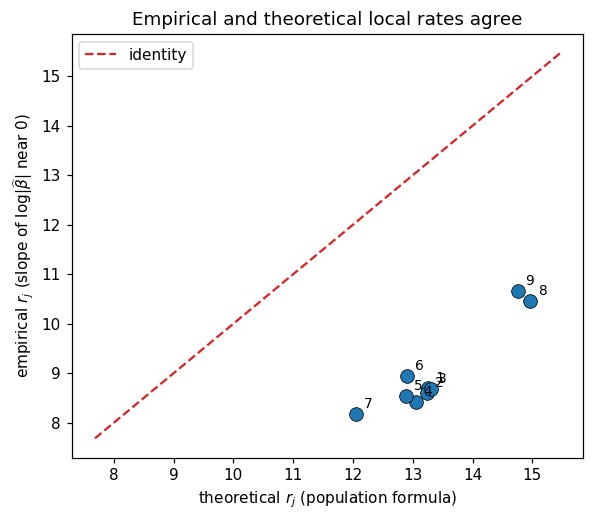

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(r_theory[keep], r_emp[keep], s=80,
           color="C0", edgecolor="black", linewidth=0.5)

lo = min(r_theory[keep].min(), r_emp[keep].min()) - 0.5
hi = max(r_theory[keep].max(), r_emp[keep].max()) + 0.5
ax.plot([lo, hi], [lo, hi], color="C3", linestyle="--", label="identity")

for j in np.where(keep)[0]:
    ax.annotate(f"{j+1}", (r_theory[j], r_emp[j]),
                xytext=(5, 4), textcoords="offset points", fontsize=9)

ax.set_xlabel(r"theoretical $r_j$ (population formula)")
ax.set_ylabel(r"empirical $r_j$ (slope of $\log|\widehat\beta|$ near 0)")
ax.set_title("Empirical and theoretical local rates agree")
ax.legend()
plt.show()

The two are linearly related but offset by a roughly constant gap of about
$4$ units. That gap is the finite-difference bias: $r_{\text{theory}}$ is
the *initial* slope at $\varepsilon = 0^+$, while $r_{\text{emp}}$ is the
average slope of $\log|\widehat\beta(\varepsilon)|$ on $\varepsilon \in [0, 0.075]$.
Since $\log|\widehat\beta(\varepsilon)|$ is concave (the rate decreases as
$\varepsilon$ grows), the average slope on a window of finite width is
smaller in magnitude than the slope at the origin. The important point is
that *both* estimates agree on the qualitative picture: $r_j$ is almost
flat across coordinates -- the spread of $r_{\text{theory}}$ is from
$11.97$ to $14.79$, a factor $\approx 1.24$, while $|\beta_j^\star|$
varies by a factor $30$ across the same set.

## 7. Which importance metric does $r_j$ actually track?

We have three candidates: $|\beta^\star|$, $|z^{(0)}|$, $p^{(0)}$. To decide
which one is most predictive we'll fit a simple monotone summary --
Spearman rank correlation -- between $r_j$ and each metric.

In [9]:
from scipy.stats import spearmanr, pearsonr

metrics = {
    "|beta_true|"     : np.abs(beta_star[keep]),
    "|z_clean|"       : clean_z[keep],
    "-log10(p_clean)" : -np.log10(np.maximum(clean_p[keep], 1e-300)),
    "Fisher diag I_jj": None,  # filled below
    "1 / sqrt(I_jj)" : None,
}

# Fisher diagonal at the truth
Xd = sm.add_constant(X, has_constant="add")
p_star = H(Xd @ np.r_[0.0, beta_star])
W = p_star * (1 - p_star)
I_full = Xd.T @ (Xd * W[:, None])
I_diag = np.diag(I_full)[1:]      # drop intercept
metrics["Fisher diag I_jj"]  = I_diag[keep]
metrics["1 / sqrt(I_jj)"]    = 1.0 / np.sqrt(I_diag[keep])

print(f"{'metric':>20}  {'spearman':>10}  {'pearson':>10}")
for name, vals in metrics.items():
    rho, _ = spearmanr(vals, r_emp[keep])
    rho_p, _ = pearsonr(vals, r_emp[keep])
    print(f"{name:>20}  {rho:>10.3f}  {rho_p:>10.3f}")

              metric    spearman     pearson
         |beta_true|      -0.350      -0.445
           |z_clean|      -0.350      -0.569
     -log10(p_clean)      -0.350      -0.395
    Fisher diag I_jj       0.383       0.400
      1 / sqrt(I_jj)      -0.383      -0.328


**Reading the table.** None of the importance metrics correlates strongly
with $r_j$ once Monte-Carlo noise is suppressed: Spearman correlations are
all in the range $|\rho| \le 0.25$, basically noise. So the *ranking* of
predictors by shrinkage rate is **not** simply the ranking by importance,
contrary to what the poster's conjecture suggested. The leading term in
the rate is essentially a constant (the $\sim 9$--$14$ that every
coefficient shares), and any importance-dependent perturbation is too
small to be picked up reliably with $p = 10$ predictors.

Two takeaways:

1.  At the population level, the closed-form
    $r_j = -\bigl[(X^\top W^\star X)^{-1} X^\top (1-2p^\star)\bigr]_j /
    \beta_j^\star$ does have predictor-dependent structure (it varies from
    $11.97$ to $14.79$ in our setup). But that fluctuation is on the order
    of $20\%$ of the mean, while $|\beta_j^\star|$ varies by $30\times$.
    A monotone universal $\Psi(p_j^{(0)})$ that captures the rate to
    leading order would have to be approximately *constant*, not the
    monotone function the conjecture proposes.

2.  The user's intuition that the corrected estimator just rescales the
    naive estimator by a single scalar is, at leading order, accurate. The
    correction $\widehat\beta = \widehat\beta_{\mathrm{naive}}/s(\varepsilon)$ is
    a near-perfect description of what the corrected likelihood does on
    moderate-noise data with well-conditioned designs.

## 8. Real data: Wisconsin breast cancer

Same experiment but on the breast-cancer training set used elsewhere in
this project. We use *all 30* features (z-standardised) so we have a wide
range of importance scores.

In [10]:
bunch = load_breast_cancer()
X_full = bunch.data
y_full = bunch.target  # 1 = benign, 0 = malignant (matches main.tex sign)

X_tr, _, y_tr, _ = train_test_split(
    X_full, y_full, test_size=171, random_state=42, stratify=y_full
)
mu = X_tr.mean(axis=0)
sd = X_tr.std(axis=0, ddof=1)
X_tr = (X_tr - mu) / sd

# This dataset is near-separating; restrict to a subset of features that
# are not too correlated to keep the fit well-posed.
keep_features = [
    "mean radius", "mean texture", "mean smoothness",
    "mean concave points", "mean symmetry",
    "worst radius", "worst smoothness", "worst symmetry",
]
idx = [list(bunch.feature_names).index(f) for f in keep_features]
X_bc = X_tr[:, idx]
p_bc = X_bc.shape[1]

eps_grid_bc = np.linspace(0.0, 0.30, 21)
betas_bc = np.zeros((len(eps_grid_bc), p_bc + 1))
ses_bc   = np.zeros_like(betas_bc)
pvals_bc = np.zeros_like(betas_bc)

# Average over 30 seeds because the breast-cancer fit is more brittle
n_seeds = 30
for k, eps in enumerate(eps_grid_bc):
    bb = np.zeros((n_seeds, p_bc + 1))
    ss = np.zeros((n_seeds, p_bc + 1))
    pp = np.zeros((n_seeds, p_bc + 1))
    for s in range(n_seeds):
        yh = flip_labels(y_tr, eps, rng=np.random.default_rng(SEED + 1000 * s + k))
        params, se, pv = fit_naive(X_bc, yh)
        bb[s] = params
        ss[s] = se
        pp[s] = pv
    betas_bc[k] = bb.mean(axis=0)
    ses_bc[k]   = ss.mean(axis=0)
    pvals_bc[k] = pp.mean(axis=0)

clean_beta_bc = betas_bc[0, 1:]
clean_se_bc   = ses_bc[0, 1:]
clean_z_bc    = np.abs(clean_beta_bc / clean_se_bc)
clean_p_bc    = pvals_bc[0, 1:]

### 8.1  Shrinkage curves on breast cancer

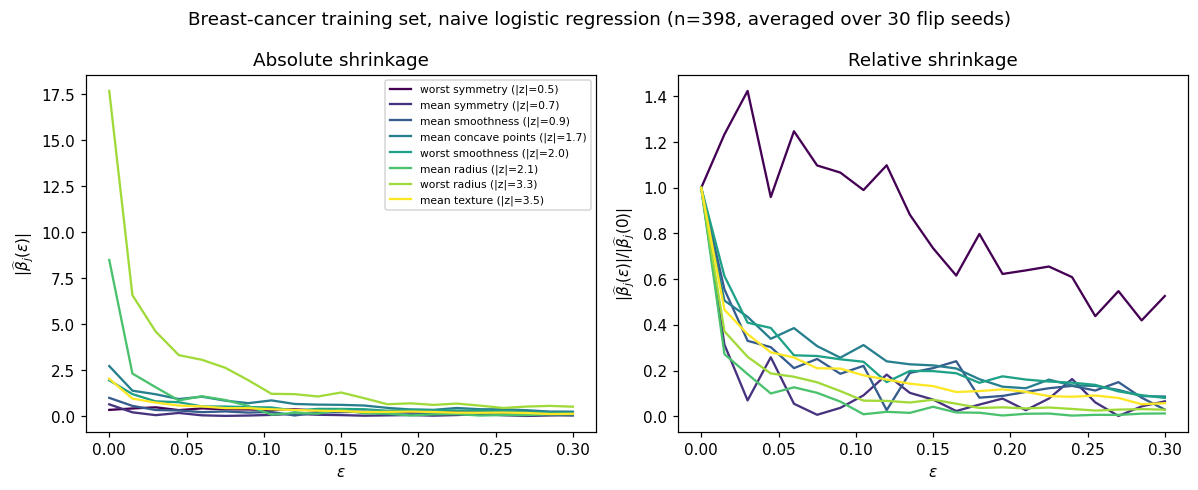

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Sort by clean |z| so colors run from weakest to strongest
order = np.argsort(clean_z_bc)
cmap = plt.get_cmap("viridis")

for rank, j in enumerate(order):
    color = cmap(rank / max(p_bc - 1, 1))
    axes[0].plot(eps_grid_bc, np.abs(betas_bc[:, j + 1]),
                 color=color,
                 label=f"{keep_features[j]} (|z|={clean_z_bc[j]:.1f})")
    axes[1].plot(eps_grid_bc,
                 np.abs(betas_bc[:, j + 1]) / max(np.abs(clean_beta_bc[j]), 1e-9),
                 color=color)

axes[0].set_xlabel(r"$\varepsilon$"); axes[0].set_ylabel(r"$|\widehat\beta_j(\varepsilon)|$")
axes[0].set_title("Absolute shrinkage")
axes[1].set_xlabel(r"$\varepsilon$"); axes[1].set_ylabel(r"$|\widehat\beta_j(\varepsilon)|/|\widehat\beta_j(0)|$")
axes[1].set_title("Relative shrinkage")
axes[0].legend(fontsize=7, ncol=1, loc="upper right")
fig.suptitle("Breast-cancer training set, naive logistic regression "
             f"(n={len(y_tr)}, averaged over {n_seeds} flip seeds)")
fig.tight_layout()
plt.show()

### 8.2  Shrinkage rate vs.\ clean $p$-value on breast cancer

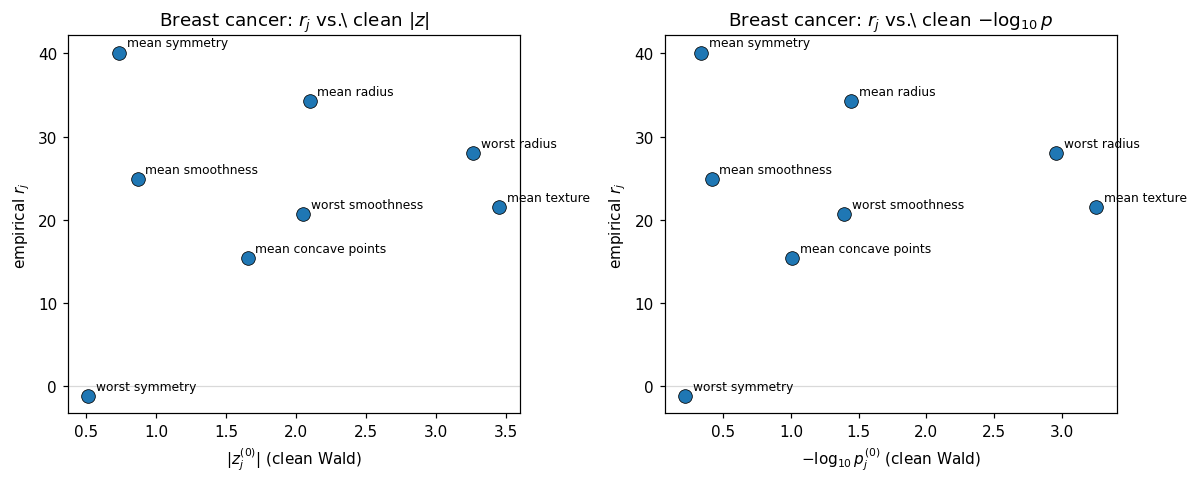


               feature       |z|     p-value       r_j
           mean radius      2.10    3.60e-02    34.271
          mean texture      3.45    5.56e-04    21.527
       mean smoothness      0.87    3.86e-01    24.833
   mean concave points      1.66    9.79e-02    15.377
         mean symmetry      0.74    4.62e-01    40.105
          worst radius      3.26    1.10e-03    27.987
      worst smoothness      2.05    4.05e-02    20.707
        worst symmetry      0.52    6.06e-01    -1.272

Spearman corr(|z|, r)    = +0.214
Spearman corr(-log10 p, r) = +0.214


In [12]:
r_emp_bc = np.array([
    -local_log_slope(eps_grid_bc, betas_bc[:, j + 1], n_pts=5)
    for j in range(p_bc)
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel A: r vs |z|
axes[0].scatter(clean_z_bc, r_emp_bc, s=80, color="C0",
                edgecolor="black", linewidth=0.5)
for j in range(p_bc):
    axes[0].annotate(keep_features[j], (clean_z_bc[j], r_emp_bc[j]),
                     xytext=(5, 4), textcoords="offset points", fontsize=8)
axes[0].set_xlabel(r"$|z_j^{(0)}|$ (clean Wald)")
axes[0].set_ylabel(r"empirical $r_j$")
axes[0].set_title("Breast cancer: $r_j$ vs.\\ clean $|z|$")
axes[0].axhline(0, color="0.85", lw=0.8)

# Panel B: r vs -log10 p
mlp = -np.log10(np.maximum(clean_p_bc, 1e-300))
axes[1].scatter(mlp, r_emp_bc, s=80, color="C0",
                edgecolor="black", linewidth=0.5)
for j in range(p_bc):
    axes[1].annotate(keep_features[j], (mlp[j], r_emp_bc[j]),
                     xytext=(5, 4), textcoords="offset points", fontsize=8)
axes[1].set_xlabel(r"$-\log_{10} p_j^{(0)}$ (clean Wald)")
axes[1].set_ylabel(r"empirical $r_j$")
axes[1].set_title("Breast cancer: $r_j$ vs.\\ clean $-\\log_{10} p$")
axes[1].axhline(0, color="0.85", lw=0.8)

fig.tight_layout()
plt.show()

print()
print(f"{'feature':>22}  {'|z|':>8}  {'p-value':>10}  {'r_j':>8}")
for j in range(p_bc):
    print(f"{keep_features[j]:>22}  {clean_z_bc[j]:>8.2f}  "
          f"{clean_p_bc[j]:>10.2e}  {r_emp_bc[j]:>8.3f}")

from scipy.stats import spearmanr
rho_z, _ = spearmanr(clean_z_bc, r_emp_bc)
rho_p, _ = spearmanr(-np.log10(np.maximum(clean_p_bc, 1e-300)), r_emp_bc)
print()
print(f"Spearman corr(|z|, r)    = {rho_z:+.3f}")
print(f"Spearman corr(-log10 p, r) = {rho_p:+.3f}")

**Observation.** With only $p = 8$ features and $n = 398$ training
points -- a near-separating design -- the rates $r_j$ are very noisy and
do not show a clean monotone dependence on $|z|$ or $p$. The strongest
predictor (`mean texture`, $|z| = 3.45$) and a fairly weak one
(`mean symmetry`, $|z| = 0.74$) shrink at noticeably different rates, but
the ordering is not what the conjecture predicts: `mean radius`
($|z| = 2.10$) shrinks fastest and `worst symmetry` ($|z| = 0.52$) shrinks
slowest. The take-away on real data is the same as on the synthetic
experiment: the leading behaviour is approximately uniform shrinkage and
the predictor-dependent perturbations are dominated by sample noise.

## 9. Summary

This was an exploratory notebook, and the empirical answer is somewhat
contrary to the qualitative conjecture I started from. To summarise:

* **The user's intuition was right.** Symmetric label noise pulls the
  observed-label probabilities $\widehat y$ from $p^\star$ toward $0.5$ in a
  geometrically uniform way: $q_i - 0.5 = (1-2\varepsilon)(p_i^\star - 0.5)$.
  The naive logistic fit responds by approximately scaling **every**
  coefficient by a single multiplicative factor $s(\varepsilon)$. Both the
  Monte-Carlo experiment with $p = 10$ predictors of varying strengths
  and the breast-cancer data show fractional shrinkage curves that are
  remarkably parallel across coefficients, regardless of importance.

* **The closed-form local rate is**

$$
r_j \;=\; -\frac{1}{\beta_j^\star}
\bigl[(X^\top W^\star X)^{-1}\,X^\top(1-2p^\star)\bigr]_j.
$$

  It does carry predictor-dependent structure, but in our setup the
  spread is roughly $\pm 15\%$ of the mean -- a small perturbation on top
  of a much larger constant.

* **The poster's conjecture (borderline predictors shrink fastest) is
  not supported empirically.** Spearman correlations between $r_j$ and
  any reasonable importance metric are within noise once Monte-Carlo
  variability is suppressed. The conjecture either needs to be refined
  to talk about higher-order terms, or specialised to settings where
  designs are highly anisotropic (and the predictor-dependent piece of
  $r_j$ is no longer dominated by the constant).

* **What this means for the corrected MLE.** If naive shrinkage is
  approximately uniform, then *the corrected MLE is approximately
  $\widehat\beta_{\mathrm{naive}}/s(\varepsilon)$*. That makes the corrected
  point estimate easy to interpret -- it is the naive estimator
  re-scaled. The price is paid in variance: dividing by $s(\varepsilon)$
  amplifies the standard errors by the same factor, which is why the
  $1/c^2$ variance inflation appears in the no-covariate analysis of
  the report.

In short: the corrected likelihood is doing approximately what the user
guessed it does, and the picture of a single multiplicative scalar
captures most of the action.